# Example Fire Analysis (Palisades & Eaton, Jan 2025)

This notebook demonstrates the **complete EMBER pipeline** end-to-end, from raw GPS trajectories and spatial data to visualisations.

**Pipeline**

```
home.csv ─────────────────┐
                          ├──► ember.zones.classify_zones()
Fire_Timeline/ ───────────┘            │
                                       ▼
dau_during_fire.csv ──► ember.pipeline.compute_stops()
                                       │
                                       ▼
                          ember.pipeline.infer_metrics()
                                       │
                                       ▼
                          ember.behavior.classify()   ── verify
                          ember.departure.delay_hours()── verify
                          ember.metrics.*              ── visualise
```

---
## 1 · Setup & Imports

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Ensure the EMBER package is importable
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

# EMBER modules
import ember.io         as eio
import ember.zones      as ezones
import ember.behavior   as ebehavior
import ember.departure  as edeparture
import ember.metrics    as emetrics
import importlib
import ember.pipeline   as epipe
importlib.reload(emetrics)
importlib.reload(ezones)
importlib.reload(ebehavior)
importlib.reload(epipe)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

DATA_DIR = os.path.join(os.getcwd(), 'data')
print(f'Data directory : {DATA_DIR}')
print(f'Contents       : {os.listdir(DATA_DIR)}')

Data directory : /Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/data
Contents       : ['Altadena_Bingtiles', 'dau_during_fire.csv', 'evacuation_metrics.csv', 'home.csv', 'Fire_Timeline']


---
## 2 · Load Raw Data

We start from three raw files:

| File | Description | Size |
|------|-------------|------|
| `home.csv` | GHOST-inferred home locations | 8 MB |
| `Fire_Timeline/` | Evacuation-zone GeoJSONs over time | 10 files |
| `dau_during_fire.csv` | Raw GPS trajectories during the fire | ~4 GB |

In [2]:
# 2a — Home locations (GHOST-inferred)
homes = eio.load_homes(os.path.join(DATA_DIR, 'home.csv'))
print(f'Loaded {len(homes):,} home locations')
homes.head(3)

Loaded 66,519 home locations


,ID,home_lat_3857,home_lon_3857,home_lat_4326,home_lon_4326,num_nights,stay_time,geometry
0,000319d0-4c4b-36d5-b6c8-65549e19db69,4.086216e+06,-1.318569e+07,34.426508,-118.449058,15,1220776.0,POINT (-118.44906 34.42651)
1,0003f99b-9763-3315-ae76-be448ff58025,4.041336e+06,-1.317715e+07,34.093291,-118.372357,14,1581425.0,POINT (-118.37236 34.09329)
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,4.058199e+06,-1.315792e+07,34.218646,-118.199613,22,1762800.0,POINT (-118.19961 34.21865)


In [3]:
# 2b — Fire timeline (evacuation-zone polygons over time)
timeline_dir = os.path.join(DATA_DIR, 'Fire_Timeline')
fire_zones = eio.load_fire_timeline(timeline_dir)
print(f'Loaded {len(fire_zones)} zone snapshots from {len(os.listdir(timeline_dir))} GeoJSON files')
fire_zones[['zoneId', 'most_extreme_status', 'incident_name', 'datetime']].head(8)

Loaded 187 zone snapshots from 10 GeoJSON files


,zoneId,most_extreme_status,incident_name,datetime
85,US-CA-XLA-TOP-U009,Evacuation Order,PALISADES,2025-01-07 12:00:00
81,US-CA-XLA-TOP-U007,Evacuation Order,PALISADES,2025-01-07 12:00:00
82,US-CA-XLA-SSM-U010,Evacuation Order,PALISADES,2025-01-07 12:00:00
84,US-CA-XLA-LOS-Q0767,Evacuation Order,PALISADES,2025-01-07 12:37:00
83,US-CA-XLA-MAL-C111,Evacuation Order,PALISADES,2025-01-07 12:37:00
183,US-CA-XLA-TOP-U004,Evacuation Order,PALISADES,2025-01-07 17:48:00
166,US-CA-XLA-LOS-Q1057,Evacuation Order,PALISADES,2025-01-07 17:48:00
167,US-CA-XLA-RMB-U030,Evacuation Order,PALISADES,2025-01-07 17:48:00


In [4]:
# 2c — Raw GPS trajectories
dau = epipe.load_gps_csv(os.path.join(DATA_DIR, 'dau_during_fire.csv'))
dau.head(3)

Loading GPS data from /Users/mustafasameen/UF Dropbox/Mustafa Sameen/projects/LA Fire/ember/examples/data/dau_during_fire.csv …


  → 32,578,795 pings, 61,674 unique devices


,ID,LAT,LONG,TIMESTAMP,GEOHASH,datetime,Date
0,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410915,-118.443283,1736177114000,9q5gbb24p,2025-01-06 07:25:14,2025-01-06
1,000319d0-4c4b-36d5-b6c8-65549e19db69,34.413055,-118.426926,1736177125000,9q5gc0sns,2025-01-06 07:25:25,2025-01-06
2,000319d0-4c4b-36d5-b6c8-65549e19db69,34.410912,-118.430511,1738022220000,9q5gc03d1,2025-01-27 15:57:00,2025-01-27


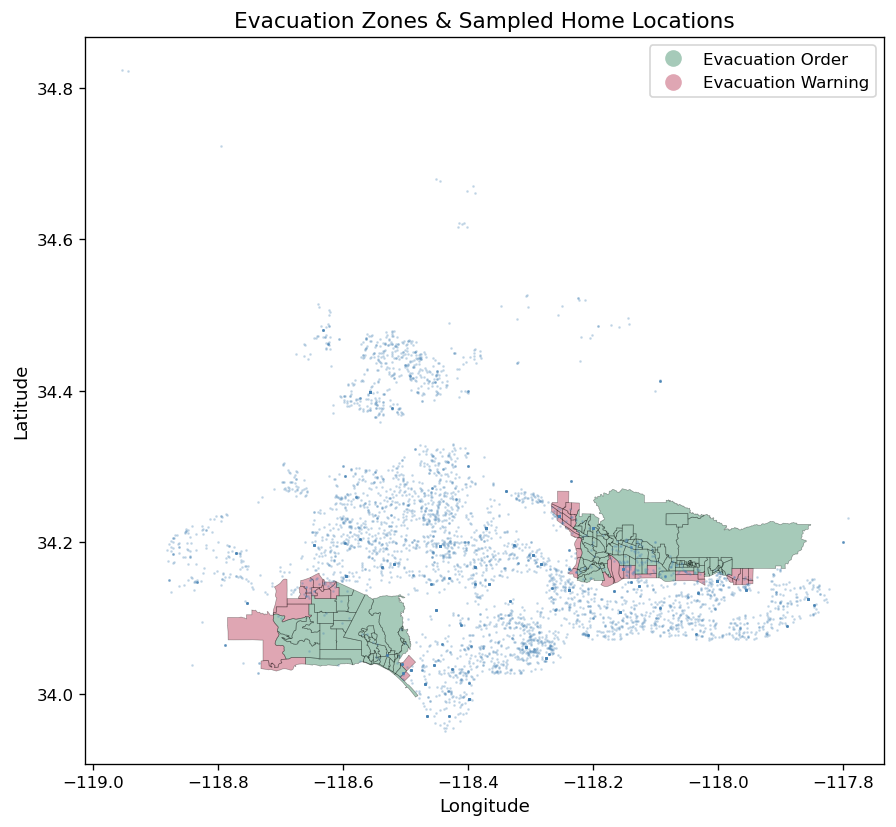

In [5]:
# Quick map of zone extents + sampled home points
fig, ax = plt.subplots(figsize=(10, 7))
fire_zones.plot(ax=ax, column='most_extreme_status', alpha=0.35,
                legend=True, cmap='RdYlGn_r', edgecolor='k', linewidth=0.4)
homes.sample(min(5000, len(homes))).plot(ax=ax, markersize=0.3, color='steelblue', alpha=0.3)
ax.set_title('Evacuation Zones & Sampled Home Locations')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

---
## 3 · Zone Classification

`ember.zones.classify_zones()` assigns each home to one of:

| Zone | Meaning |
|------|--------|
| **Order** | Mandatory evacuation issued |
| **Warning** | Voluntary evacuation advisory |
| **Buffer** | Within buffer distance of active zones |
| **Outside** | Beyond buffer — not in study population |

In [6]:
# Run zone classification
homes_classified = ezones.classify_zones(
    homes,
    fire_zones,
    buffer_distance=2000  # 2 km buffer
)

# Drop residents outside the study area
study_pop = homes_classified[homes_classified['ZoneType'] != 'Outside'].copy()
print(f'Study population: {len(study_pop):,} / {len(homes_classified):,} homes')
print()
print(study_pop['ZoneType'].value_counts())

Study population: 9,995 / 66,519 homes

ZoneType
Buffer     5622
Order      2332
Warning    2041
Name: count, dtype: int64


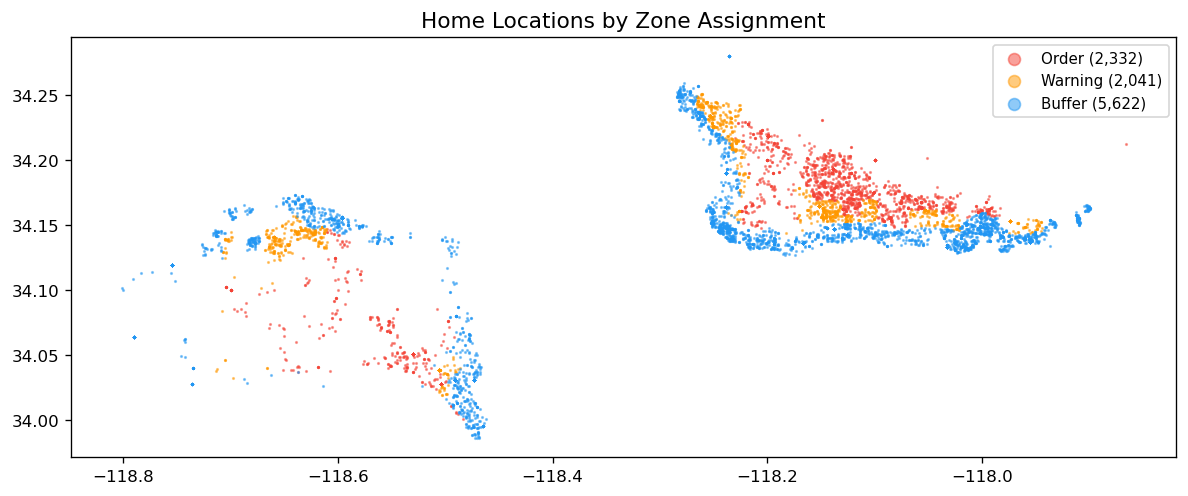

In [7]:
# Visualise zone assignment
zone_colors = {'Order': '#F44336', 'Warning': '#FF9800', 'Buffer': '#2196F3'}
fig, ax = plt.subplots(figsize=(10, 7))
for zt, color in zone_colors.items():
    sub = study_pop[study_pop['ZoneType'] == zt]
    sub.plot(ax=ax, markersize=0.8, color=color, alpha=0.5, label=f'{zt} ({len(sub):,})')
ax.legend(markerscale=8, fontsize=9)
ax.set_title('Home Locations by Zone Assignment')
plt.tight_layout()
plt.show()

---
## 4 · Compute Evacuation Stops

`ember.pipeline.compute_stops()` merges raw GPS pings with home locations,
computes Euclidean distance from home for each ping, and flags whether the
device is outside the combined evacuation zone polygon.

This is the most compute-intensive step (~32 M pings).

In [8]:
%%time
stops = epipe.compute_stops(
    dau,
    study_pop,
    fire_zones,
    buffer_meters=2000
)
print(f'\nStop records: {len(stops):,}')
stops.head(3)

Computing stops for 9,995 residents (4,464,738 pings) …
  → 4,464,738 stop records ready

Stop records: 4,464,738
CPU times: user 7.19 s, sys: 682 ms, total: 7.87 s
Wall time: 7.39 s


,ID,LAT,LONG,TIMESTAMP,GEOHASH,datetime,Date,home_lon,home_lat,ZoneType,OrderStart,FireEvent,stop_date,lat_grid,lon_grid,dist_meters,eu_distance,is_outside_zone
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,1736132400000,9q5fkngmb,2025-01-05 19:00:00,2025-01-05,-1.315792e+07,4.058199e+06,Order,2025-01-08 06:09:00,Eaton,2025-01-05 19:00:00,34.183601,-118.296303,11751.620521,7.302116,True
1,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,1736132460000,9q5fkngmb,2025-01-05 19:01:00,2025-01-05,-1.315792e+07,4.058199e+06,Order,2025-01-08 06:09:00,Eaton,2025-01-05 19:01:00,34.183601,-118.296303,11751.620521,7.302116,True
2,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,34.183601,-118.296303,1736132520000,9q5fkngmb,2025-01-05 19:02:00,2025-01-05,-1.315792e+07,4.058199e+06,Order,2025-01-08 06:09:00,Eaton,2025-01-05 19:02:00,34.183601,-118.296303,11751.620521,7.302116,True


---
## 5 · Infer Evacuation Metrics

`ember.pipeline.infer_metrics()` iterates over each resident's trajectory,
identifies consecutive away-from-home intervals, and classifies their
evacuation behaviour into the 7-category taxonomy.

In [9]:
%%time
FIRE_STARTS = {
    'Palisades': '2025-01-07 10:30:00',
    'Eaton':     '2025-01-07 18:18:00'
}

metrics = epipe.infer_metrics(
    stops,
    fire_starts=FIRE_STARTS,
    fire_end='2025-01-14',
    min_dist_miles=0.25
)

print(f'\nTotal residents: {len(metrics):,}')
metrics.head()

Inferring metrics for 9,297 residents …
  → 2,446 evacuees / 9,297 total
Category
NER     6851
SEFN    1338
PERE     706
FEUO     144
SELE     131
FEUW     127

Total residents: 9,297
CPU times: user 5.95 s, sys: 158 ms, total: 6.11 s
Wall time: 6.1 s


,ID,Category,DepartureDate,ReturnDate,DelayHours,ZoneType,OrderStart,OrderEnd,FireEvent,fire_start,home_lon,is_evacuee
0,00075e64-d2ed-3634-a37b-f1a7b7a0b38e,NER,2025-01-05 19:00:00,2025-01-19 08:50:00,0.000000,Order,2025-01-08 06:09:00,2025-01-14 23:00:00,Eaton,2025-01-07 18:18:00,-1.315792e+07,False
1,0013c171-f175-3763-b3ef-e5a6e0081928,NER,NaT,NaT,NaN,Warning,2025-01-08 06:09:00,2025-01-14 23:00:00,Eaton,2025-01-07 18:18:00,-1.316118e+07,False
2,0016c7e3-b4f0-3fad-bb36-ba588ea62dde,SEFN,2025-01-11 12:16:03,2025-01-14 00:15:00,97.767500,Buffer,2025-01-07 10:30:00,2025-01-14 23:00:00,NaN,2025-01-07 10:30:00,-1.320202e+07,True
3,001d30d2-140e-323a-bb75-fd3aa97256f2,SEFN,2025-01-09 20:13:00,2025-01-17 21:04:00,57.716667,Buffer,2025-01-07 10:30:00,2025-01-14 23:00:00,NaN,2025-01-07 10:30:00,-1.314971e+07,True
4,002157c4-4fa3-33bf-8be9-7788188d31a8,NER,NaT,NaT,NaN,Warning,2025-01-08 06:09:00,2025-01-14 23:00:00,Eaton,2025-01-07 18:18:00,-1.316333e+07,False


In [10]:
# Behavior summary table
summary = ebehavior.summary(metrics['Category'])
summary

,Category,Count,Percentage,Description
4,SELE,131,1.41,Self-Evacuee Leaving Early
2,PERE,706,7.59,Partially-compliant Evacuee (Early Returner)
5,FEUW,127,1.37,Fully-compliant Evacuee Under Warning
3,FEUO,144,1.55,Fully-compliant Evacuee Under Order
1,SEFN,1338,14.39,Shadow Evacuee From Nearby
0,NER,6851,73.69,Non-Evacuee Resident


In [11]:
# Per-fire summary
for fire in metrics['FireEvent'].dropna().unique():
    sub = metrics[metrics['FireEvent'] == fire]
    print(f'\n── {fire} ({len(sub):,} residents) ──')
    display(ebehavior.summary(sub['Category']))


── Eaton (2,937 residents) ──


,Category,Count,Percentage,Description
4,SELE,96,3.27,Self-Evacuee Leaving Early
1,PERE,505,17.19,Partially-compliant Evacuee (Early Returner)
3,FEUW,97,3.30,Fully-compliant Evacuee Under Warning
2,FEUO,102,3.47,Fully-compliant Evacuee Under Order
0,NER,2137,72.76,Non-Evacuee Resident



── Palisades (1,090 residents) ──


,Category,Count,Percentage,Description
3,SELE,35,3.21,Self-Evacuee Leaving Early
1,PERE,201,18.44,Partially-compliant Evacuee (Early Returner)
4,FEUW,30,2.75,Fully-compliant Evacuee Under Warning
2,FEUO,42,3.85,Fully-compliant Evacuee Under Order
0,NER,782,71.74,Non-Evacuee Resident


---
## 6 · Departure Delay Verification

`ember.departure.delay_hours()` computes the signed delay between
order issuance and observed departure.

In [12]:
metrics['DelayHours_check'] = edeparture.delay_hours(
    metrics['DepartureDate'],
    metrics['OrderStart']
)

valid = metrics.dropna(subset=['DelayHours_check'])
print(f'Median delay : {valid["DelayHours_check"].median():.1f} hours')
print(f'Mean delay   : {valid["DelayHours_check"].mean():.1f} hours')
print(f'Pre-emptive  : {(valid["DelayHours_check"] < 0).sum():,} residents')

metrics.drop(columns=['DelayHours_check'], inplace=True)

Median delay : -3.1 hours
Mean delay   : 23.9 hours
Pre-emptive  : 2,534 residents


---
## 7 · Data Overview

In [13]:
print('='*50)
print(f'Total study residents : {len(metrics):,}')
print(f'Fire events           : {metrics["FireEvent"].nunique()}')
print(f'Zone types            : {metrics["ZoneType"].nunique()}')
print('='*50)
print()
pd.crosstab(metrics['FireEvent'], metrics['ZoneType'], margins=True)

Total study residents : 9,297
Fire events           : 2
Zone types            : 3



ZoneType,Order,Warning,All
FireEvent,,,
Eaton,1536,1401,2937
Palisades,591,499,1090
All,2127,1900,4027


In [14]:
pd.crosstab(metrics['FireEvent'], metrics['Category'], margins=True)

Category,FEUO,FEUW,NER,PERE,SELE,All
FireEvent,,,,,,
Eaton,102,97,2137,505,96,2937
Palisades,42,30,782,201,35,1090
All,144,127,2919,706,131,4027


---
## 8 · Compliance Analysis

In [15]:
compliance = emetrics.compliance_rate(metrics)
print('Overall compliance by zone type:')
display(compliance)

for fire in metrics['FireEvent'].dropna().unique():
    sub = metrics[metrics['FireEvent'] == fire]
    print(f'\n── {fire} ──')
    display(emetrics.compliance_rate(sub))

Overall compliance by zone type:


,ZoneType,Total_Residents,Evacuated,Compliance_Rate
0,Buffer,5270.0,1338.0,0.253890
1,Order,2127.0,562.0,0.264222
2,Warning,1900.0,546.0,0.287368



── Eaton ──


,ZoneType,Total_Residents,Evacuated,Compliance_Rate
0,Order,1536.0,399.0,0.259766
1,Warning,1401.0,401.0,0.286224



── Palisades ──


,ZoneType,Total_Residents,Evacuated,Compliance_Rate
0,Order,591.0,163.0,0.275804
1,Warning,499.0,145.0,0.290581


---
## 9 · Departure Curves


In [16]:
PALISADES_START = pd.Timestamp('2025-01-07 10:30:00')
EATON_START     = pd.Timestamp('2025-01-07 18:18:00')

night_shades = []
for d in range(7, 14):
    night_shades.append((
        pd.Timestamp(f'2025-01-{d:02d} 18:00:00'),
        pd.Timestamp(f'2025-01-{d+1:02d} 06:00:00')
    ))

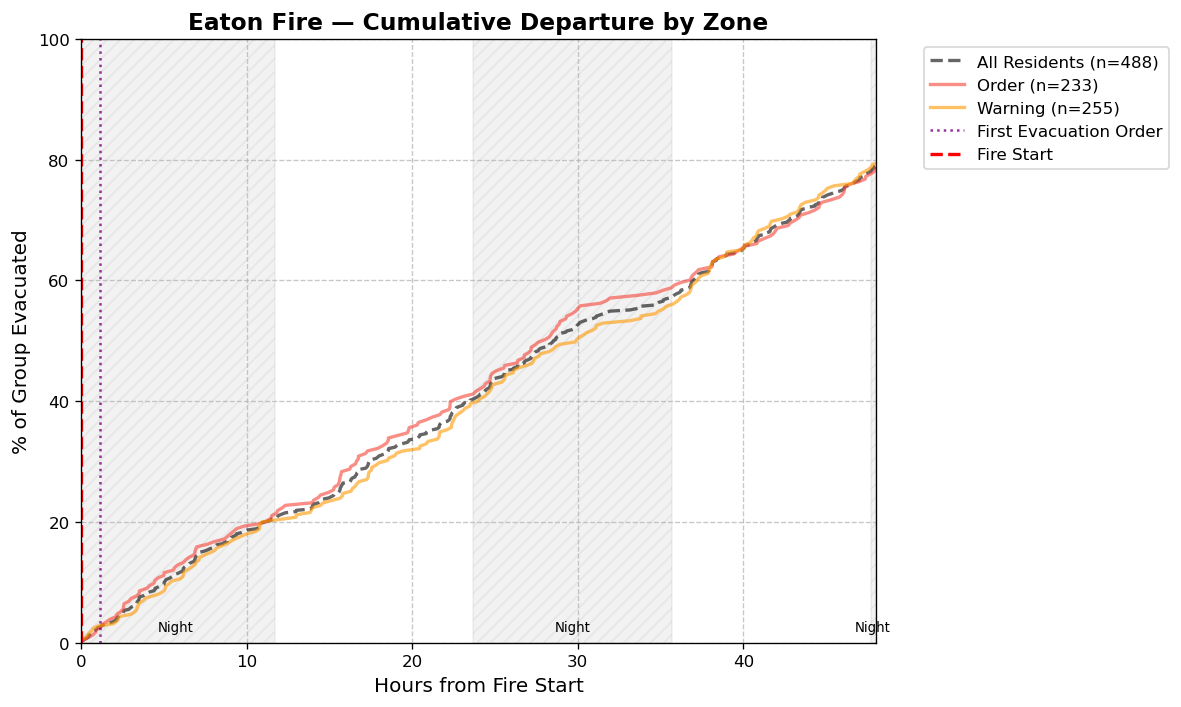

In [17]:
# Eaton Fire
eaton = metrics[metrics['FireEvent'] == 'Eaton'].copy()
emetrics.plot_departure_curve(
    df=eaton, start_ref=EATON_START,
    
    night_shades=night_shades,
    group_col='ZoneType',
    title='Eaton Fire — Cumulative Departure by Zone'
)

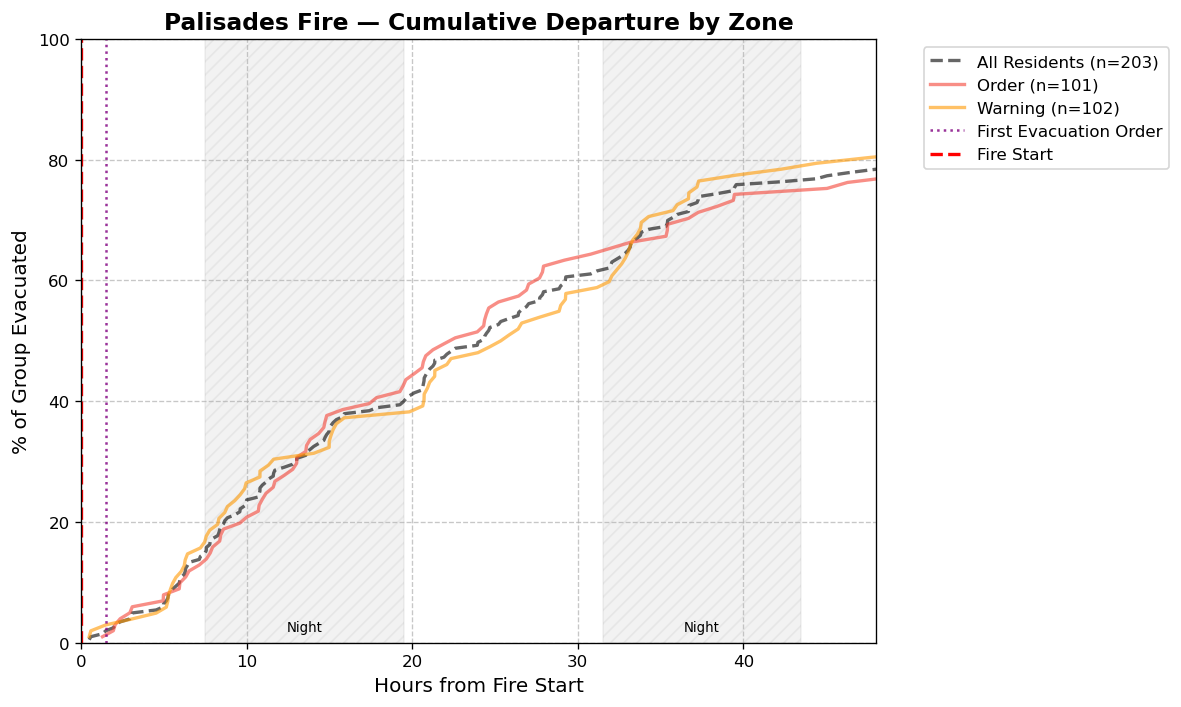

In [18]:
# Palisades Fire
palisades = metrics[metrics['FireEvent'] == 'Palisades'].copy()
emetrics.plot_departure_curve(
    df=palisades, start_ref=PALISADES_START,
    
    night_shades=night_shades,
    group_col='ZoneType',
    title='Palisades Fire — Cumulative Departure by Zone'
)

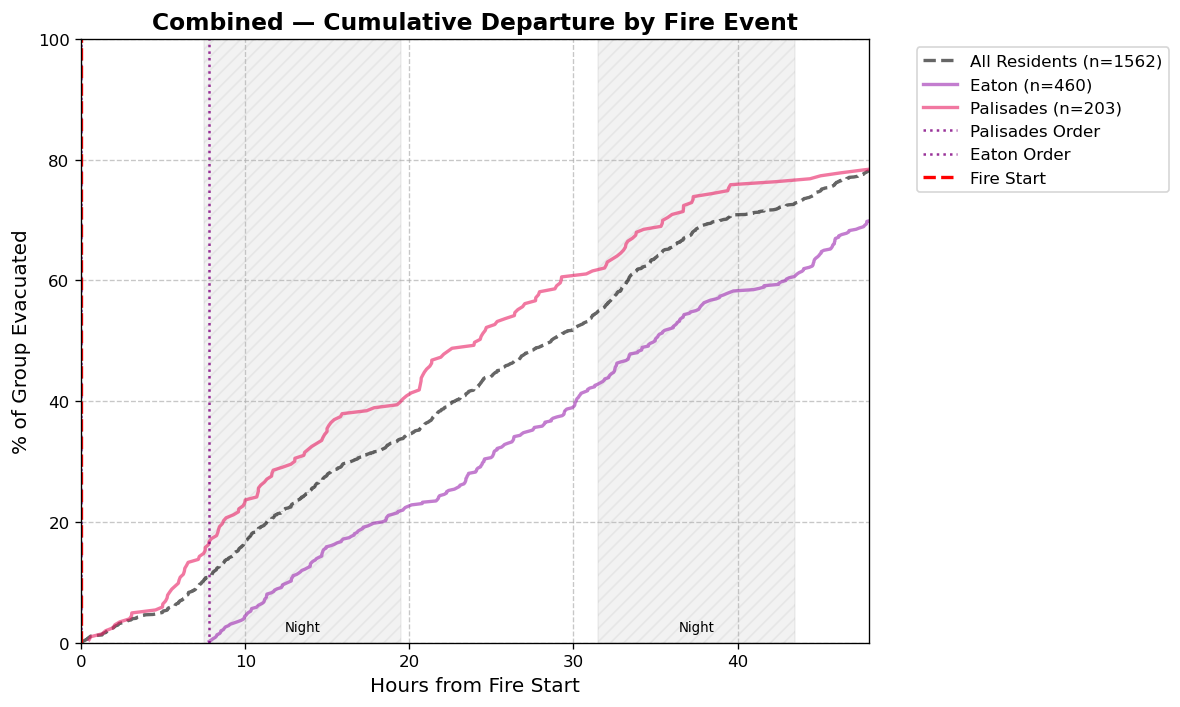

In [19]:
# Combined by fire event
emetrics.plot_departure_curve(
    df=metrics, start_ref=PALISADES_START,
    order_offsets={
        'Palisades Order': 0,
        'Eaton Order': (EATON_START - PALISADES_START).total_seconds() / 3600
    },
    night_shades=night_shades,
    group_col='FireEvent',
    title='Combined — Cumulative Departure by Fire Event'
)

---
## 10 · Evacuation Composition


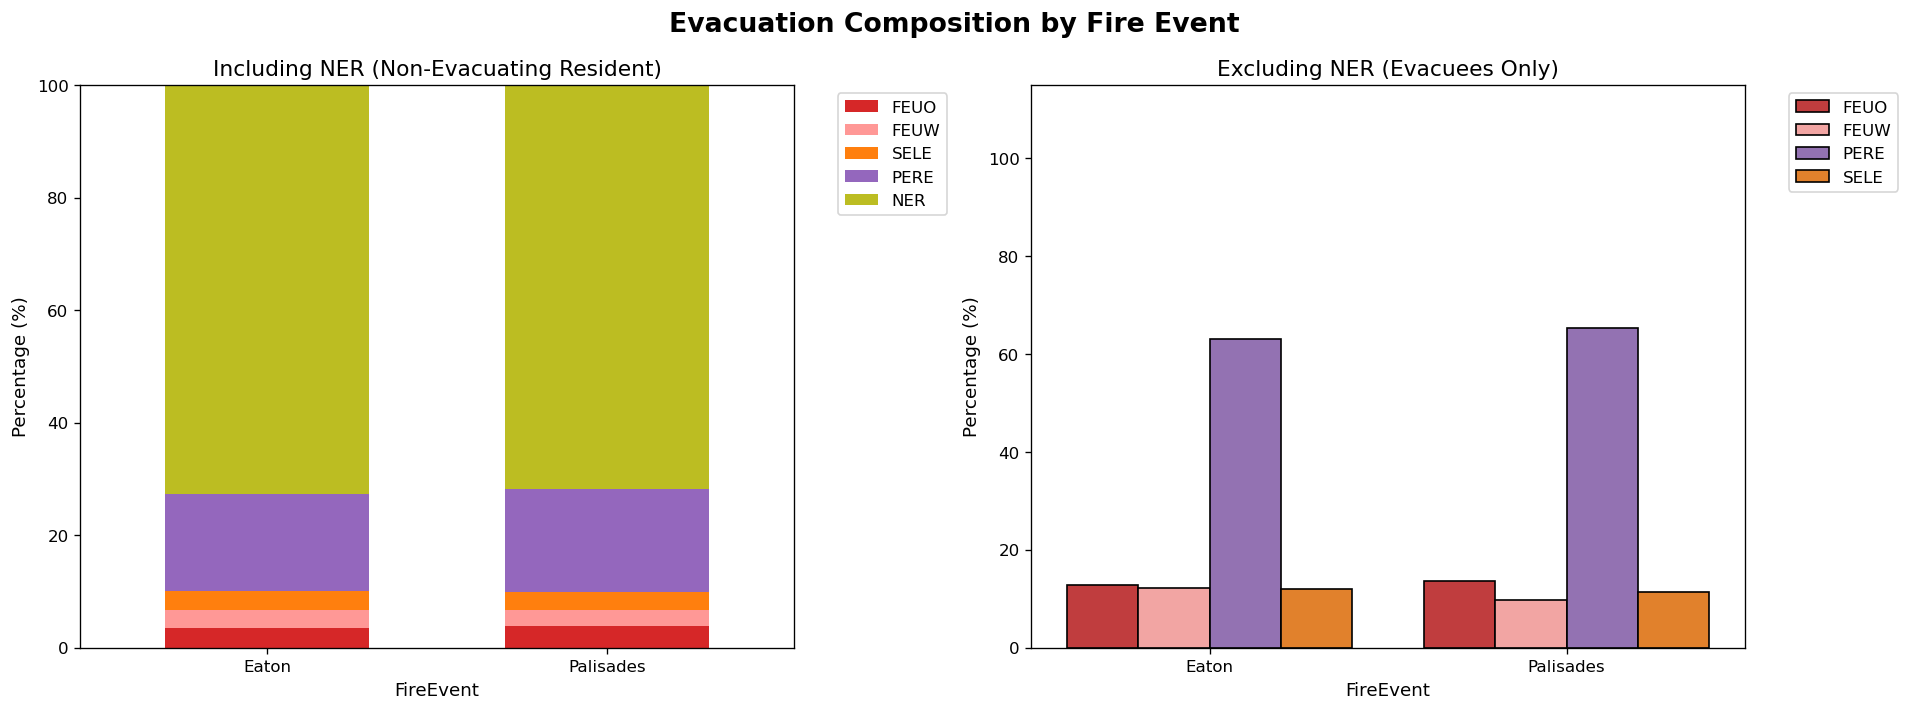

{'all': Category         FEUO       FEUW       SELE         PERE           NER
 FireEvent                                                             
 Eaton      102 (3.5%)  97 (3.3%)  96 (3.3%)  505 (17.2%)  2137 (72.8%)
 Palisades   42 (3.9%)  30 (2.8%)  35 (3.2%)  201 (18.4%)   782 (71.7%),
 'evacuees_only': Category          FEUO        FEUW        SELE         PERE
 FireEvent                                                  
 Eaton      102 (12.8%)  97 (12.1%)  96 (12.0%)  505 (63.1%)
 Palisades   42 (13.6%)   30 (9.7%)  35 (11.4%)  201 (65.3%)}

In [20]:
emetrics.plot_evacuation_composition(metrics, group_col='FireEvent', dual_panel=True,
                                     title='Evacuation Composition by Fire Event')

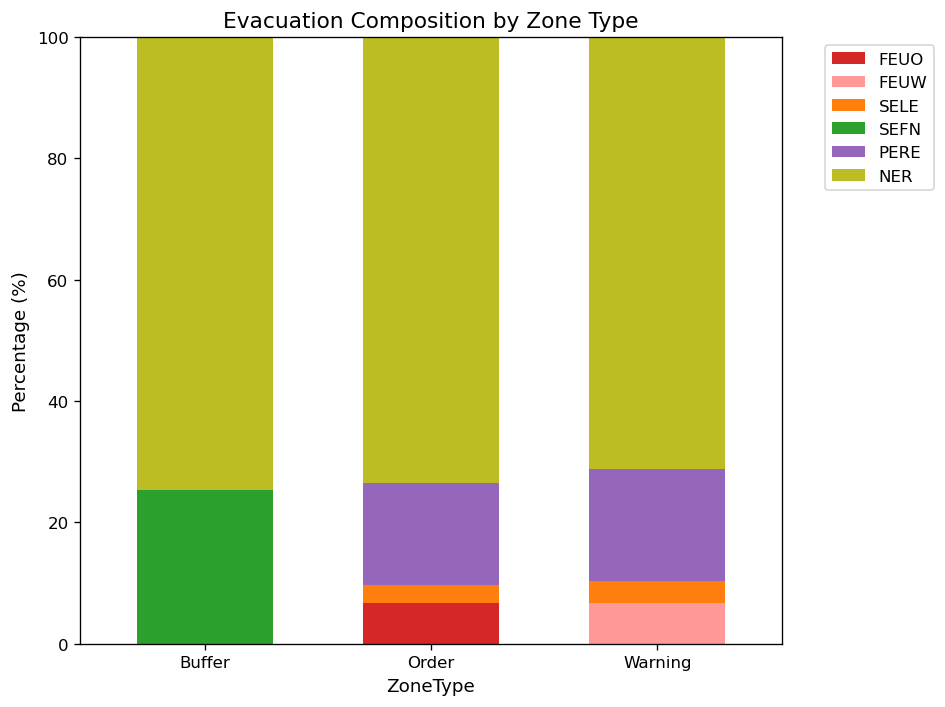

{'all': Category        FEUO        FEUW       SELE          SEFN         PERE  \
 ZoneType                                                                 
 Buffer      0 (0.0%)    0 (0.0%)   0 (0.0%)  1338 (25.4%)     0 (0.0%)   
 Order     144 (6.8%)    0 (0.0%)  61 (2.9%)      0 (0.0%)  357 (16.8%)   
 Warning     0 (0.0%)  127 (6.7%)  70 (3.7%)      0 (0.0%)  349 (18.4%)   
 
 Category           NER  
 ZoneType                
 Buffer    3932 (74.6%)  
 Order     1565 (73.6%)  
 Warning   1354 (71.3%)  }

In [21]:
emetrics.plot_evacuation_composition(metrics, group_col='ZoneType',
                                     title='Evacuation Composition by Zone Type')

---
## 11 · Delay Distribution


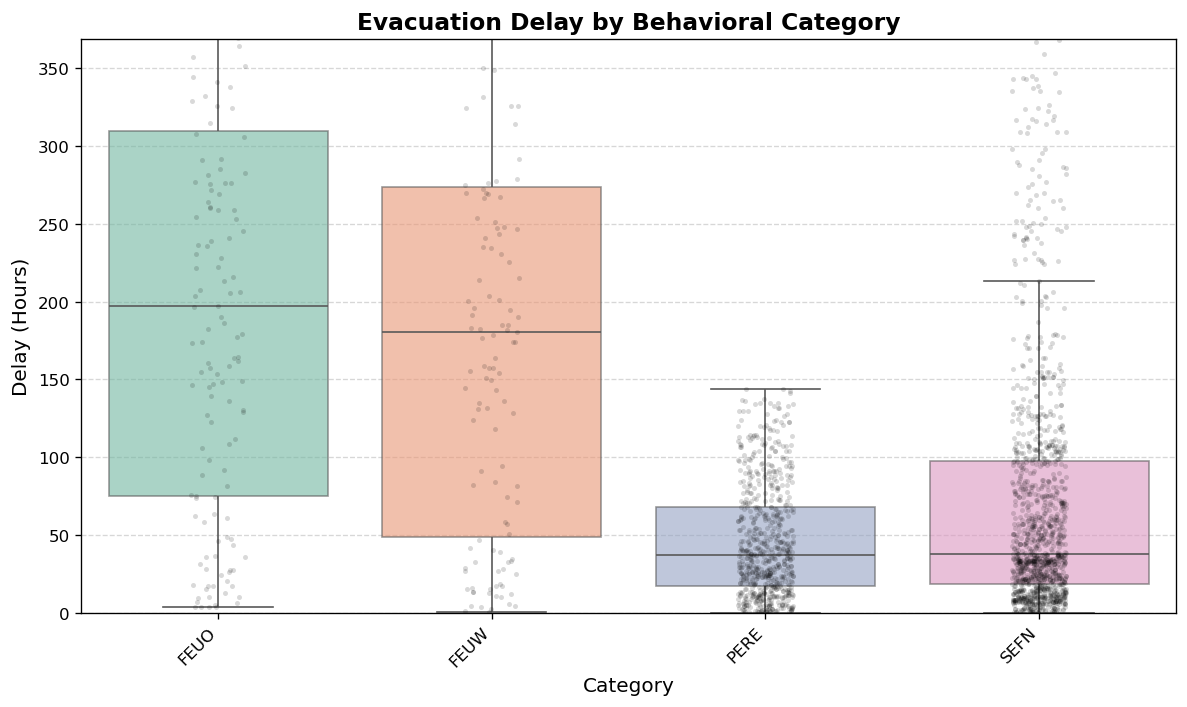

In [22]:
emetrics.plot_delay_distribution(metrics, group_col='Category',
                                 title='Evacuation Delay by Behavioral Category')

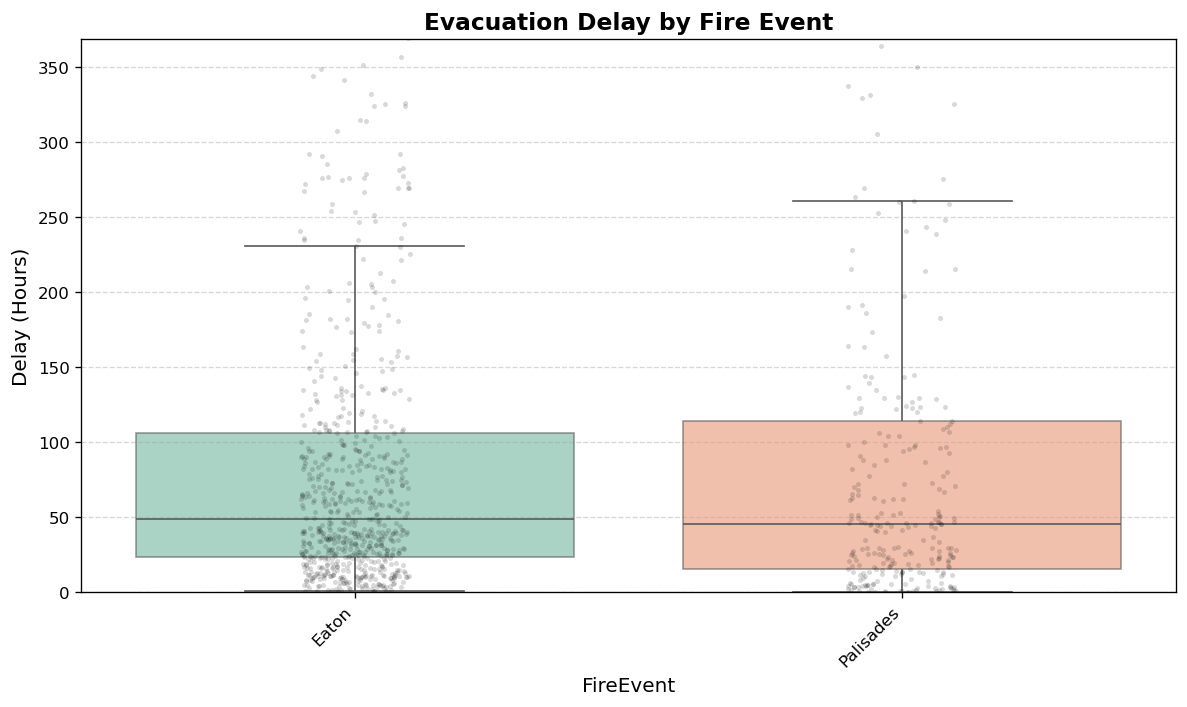

In [23]:
emetrics.plot_delay_distribution(metrics, group_col='FireEvent',
                                 title='Evacuation Delay by Fire Event')

---
## 12 · Temporal Pattern — Departure Heatmap


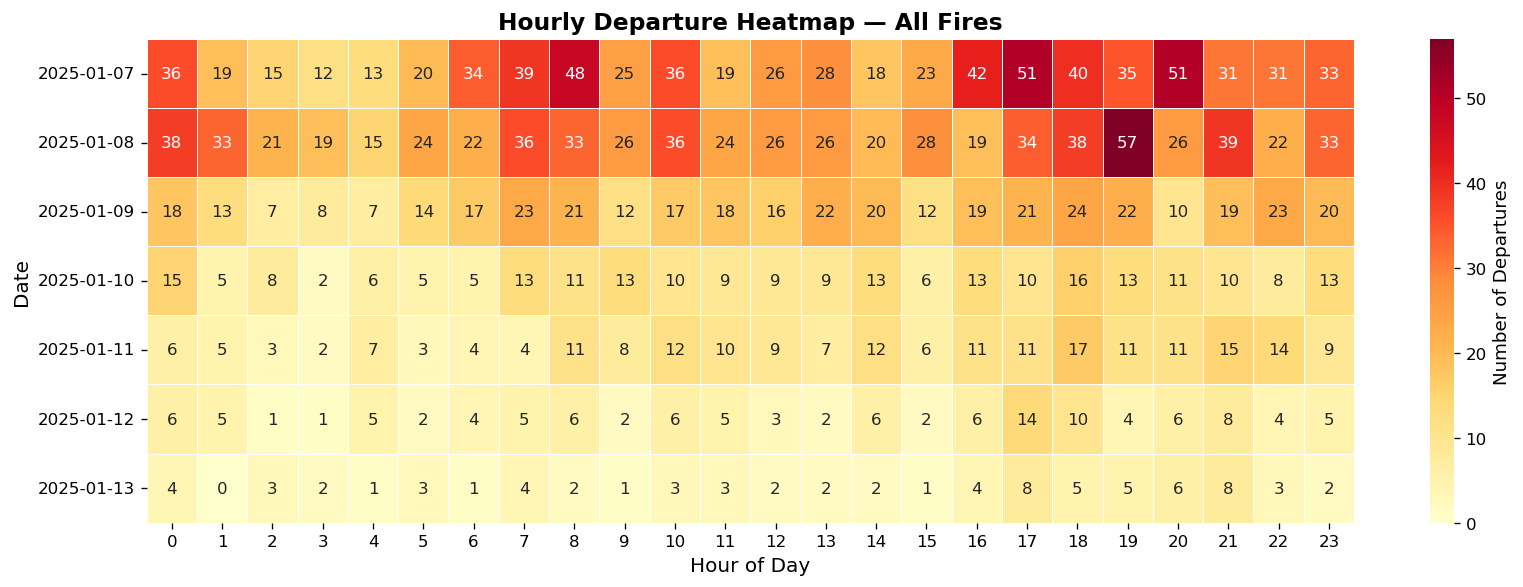

In [24]:
emetrics.plot_temporal_heatmap(metrics, fire_start='2025-01-07',
                               title='Hourly Departure Heatmap — All Fires')

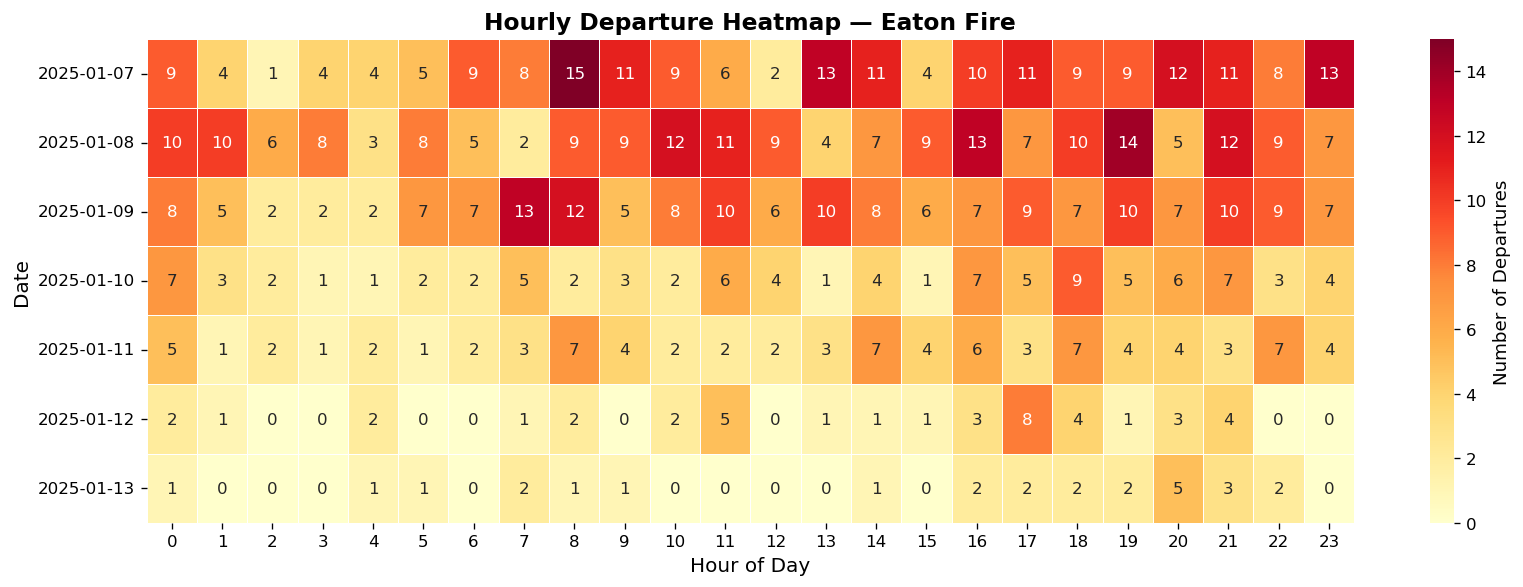

In [25]:
emetrics.plot_temporal_heatmap(eaton, fire_start='2025-01-07',
                               title='Hourly Departure Heatmap — Eaton Fire')

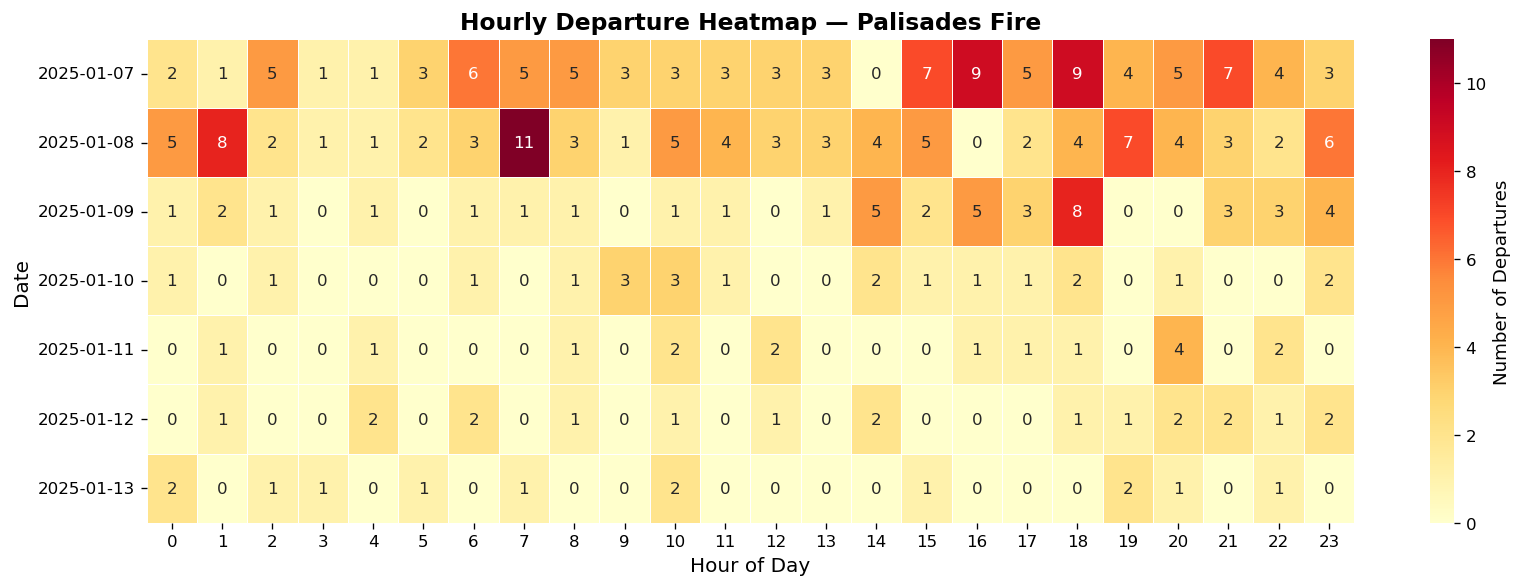

In [26]:
emetrics.plot_temporal_heatmap(palisades, fire_start='2025-01-07',
                               title='Hourly Departure Heatmap — Palisades Fire')

---
## 13 · Return Behavior Analysis


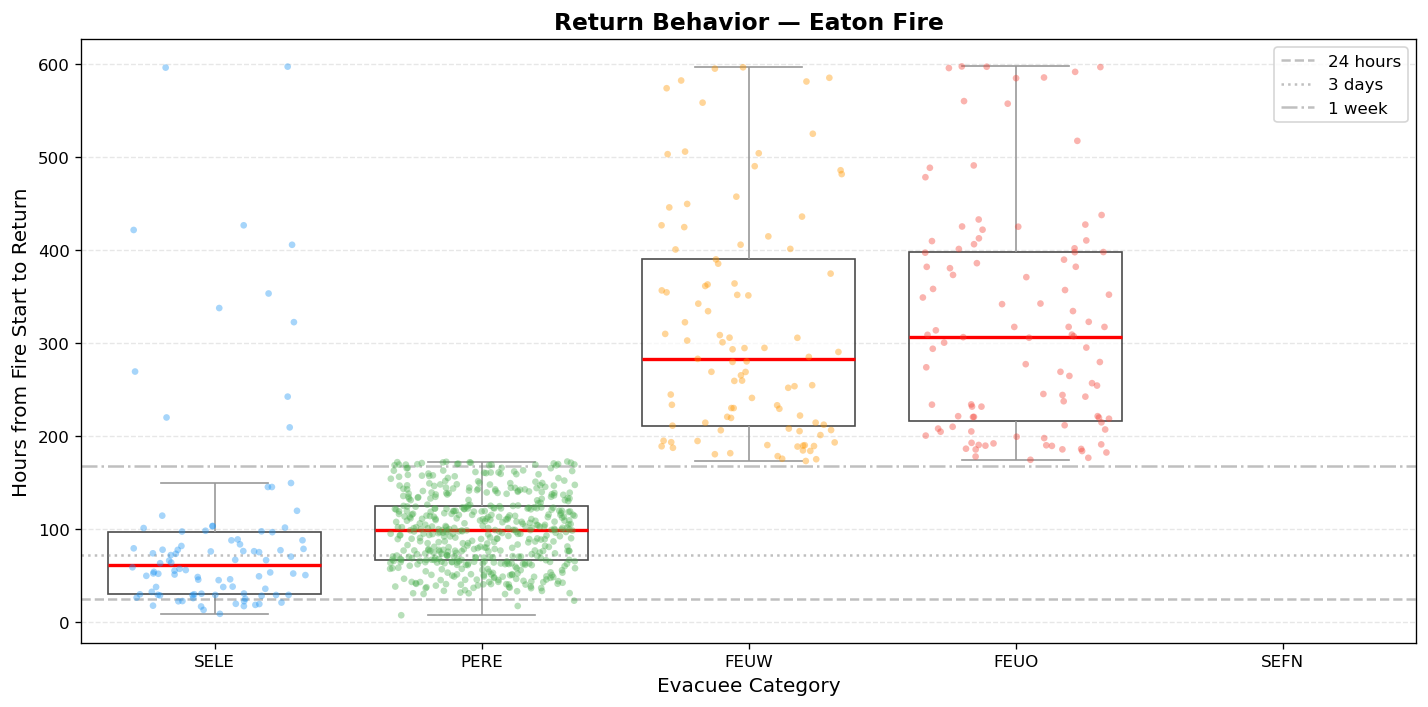

In [27]:
emetrics.plot_return_timeline(eaton, fire_start='2025-01-07 18:18:00',
                              title='Return Behavior — Eaton Fire')

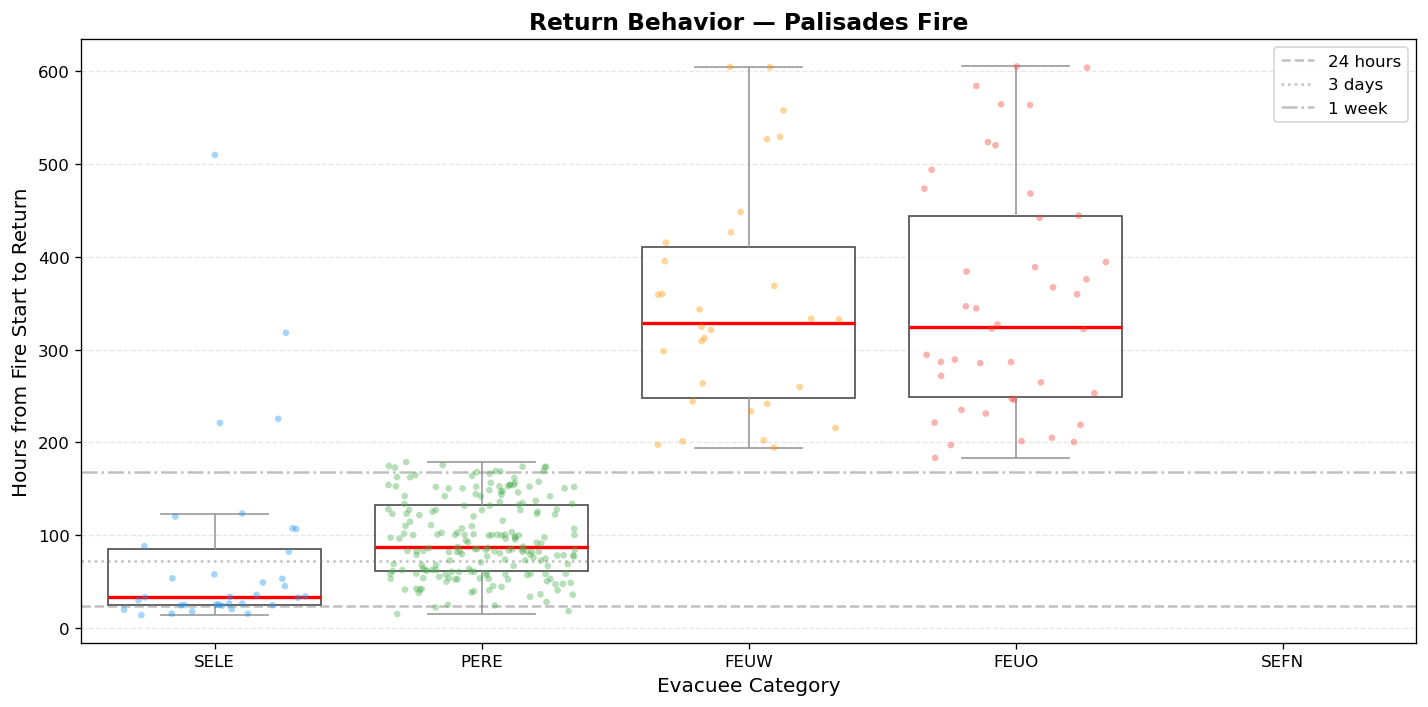

In [28]:
emetrics.plot_return_timeline(palisades, fire_start='2025-01-07 10:30:00',
                              title='Return Behavior — Palisades Fire')

## 14 · Spatial Evacuation Delay Map
Visualizing delays geographically.

Plotting Composition breakdown...


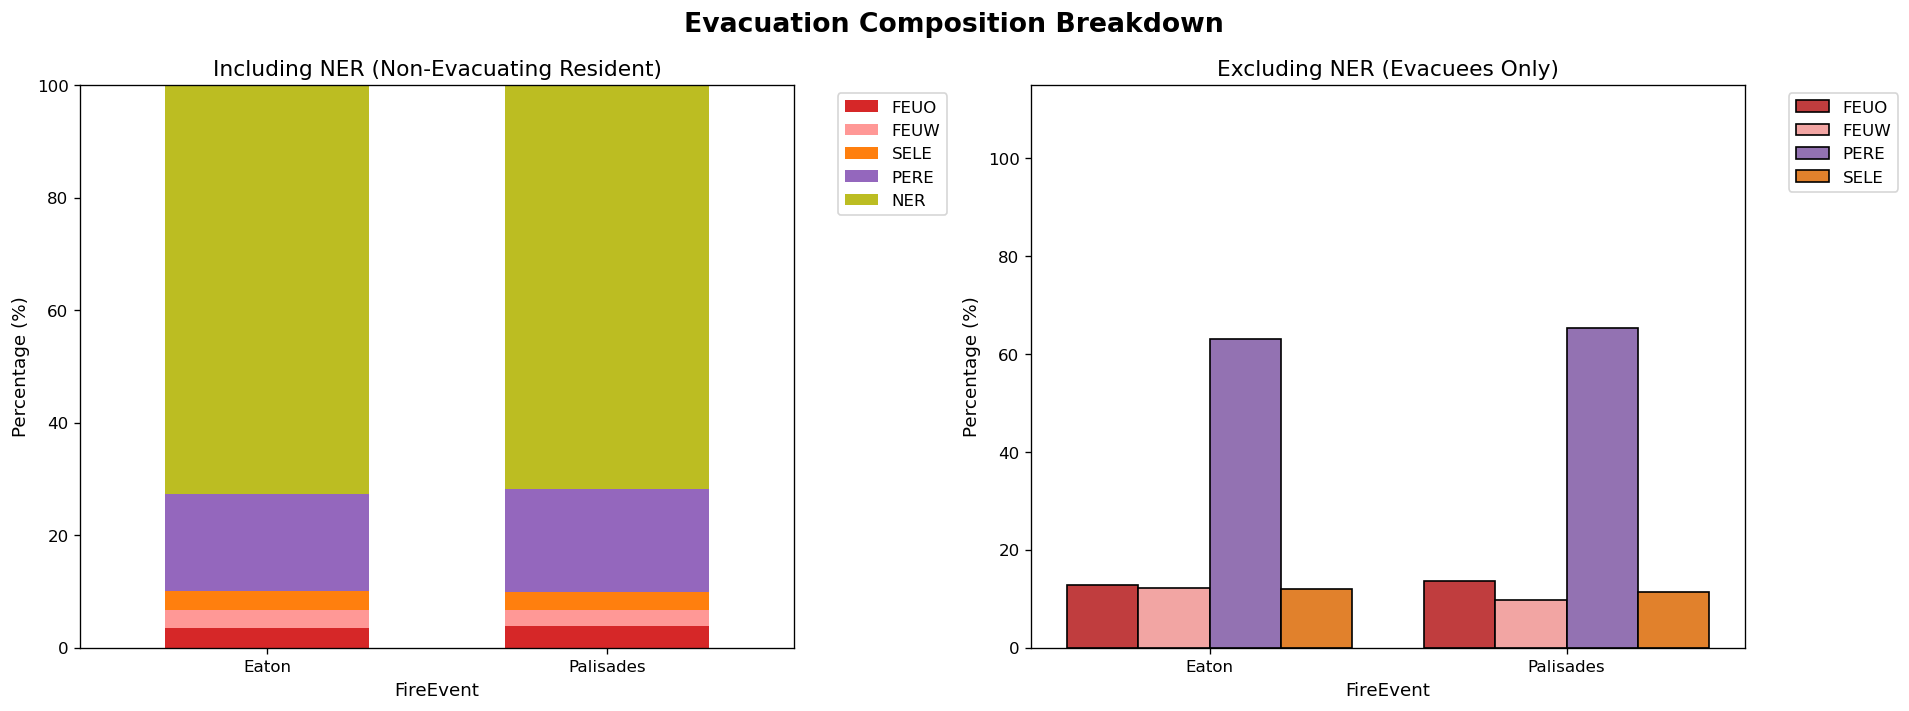


Composition Table with All Categories:


Category,FEUO,FEUW,SELE,PERE,NER
FireEvent,,,,,
Eaton,102 (3.5%),97 (3.3%),96 (3.3%),505 (17.2%),2137 (72.8%)
Palisades,42 (3.9%),30 (2.8%),35 (3.2%),201 (18.4%),782 (71.7%)



Composition Table with Evacuees Only:


Category,FEUO,FEUW,SELE,PERE
FireEvent,,,,
Eaton,102 (12.8%),97 (12.1%),96 (12.0%),505 (63.1%)
Palisades,42 (13.6%),30 (9.7%),35 (11.4%),201 (65.3%)


In [29]:
# Evacuation Composition Breakdown
print('Plotting Composition breakdown...')
composition_tables = emetrics.plot_evacuation_composition(
    metrics, 
    group_col='FireEvent', 
    dual_panel=True, 
    title="Evacuation Composition Breakdown"
)
if composition_tables:
    print("\nComposition Table with All Categories:")
    display(composition_tables['all'])
    print("\nComposition Table with Evacuees Only:")
    display(composition_tables['evacuees_only'])


Plotting Departure Timing by Category for Palisades...


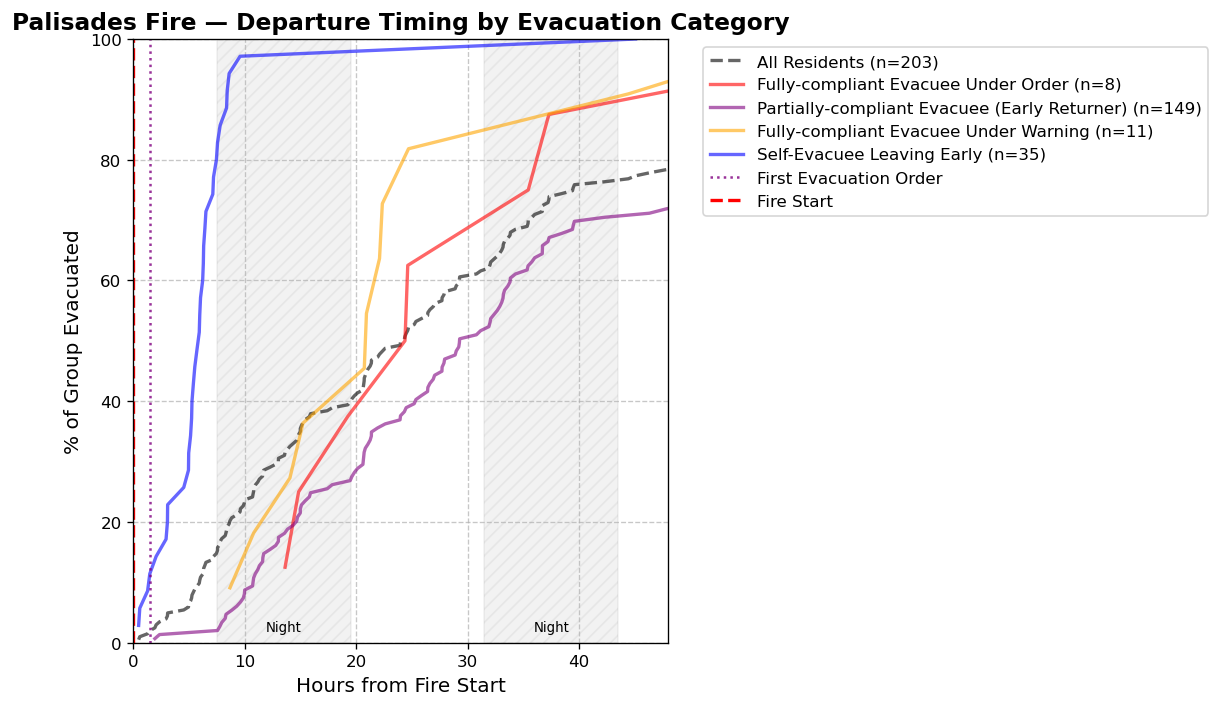

Plotting Departure Timing by Category for Eaton...


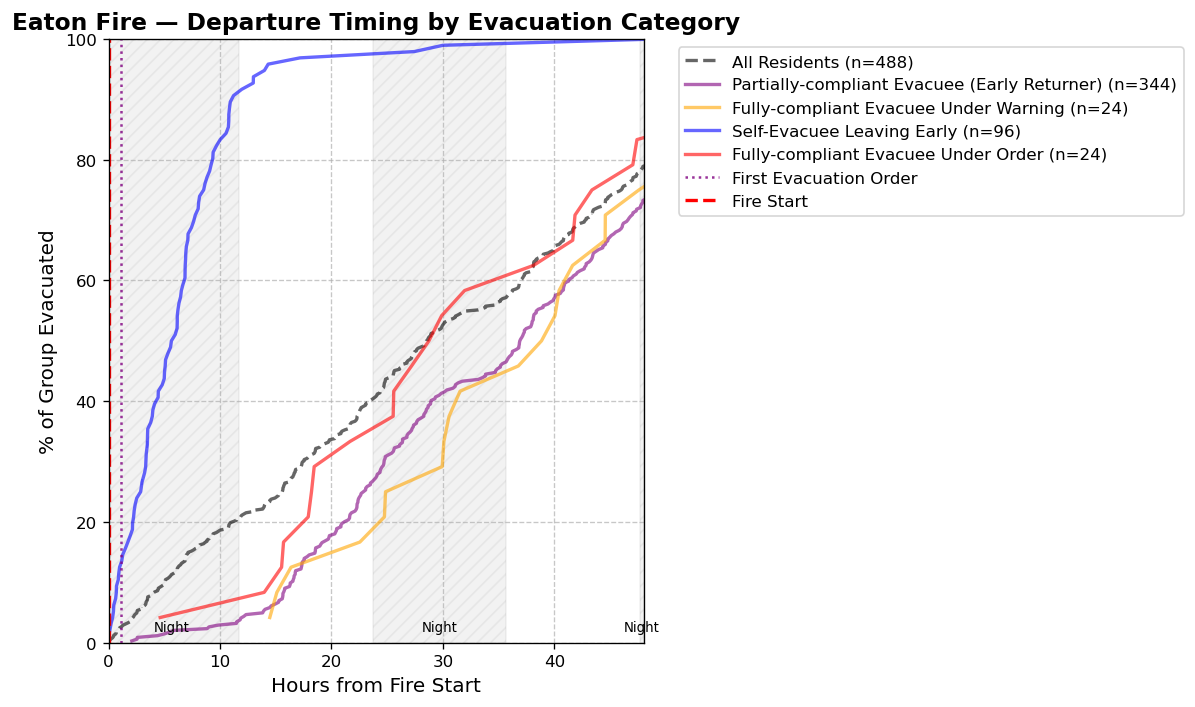

In [30]:
# Departure Timing by Evacuation Zone (Category)
metrics['Category_Name'] = metrics['Category'].map(ebehavior.CATEGORY_NAMES)
start_ref = pd.to_datetime(FIRE_STARTS['Palisades']) # Base on Palisades for combined or do separately

print('Plotting Departure Timing by Category for Palisades...')
emetrics.plot_departure_curve(
    df=metrics[metrics['FireEvent'] == 'Palisades'], 
    start_ref=pd.Timestamp(FIRE_STARTS['Palisades']), 
    night_shades=night_shades, 
    group_col='Category_Name', 
    title="Palisades Fire — Departure Timing by Evacuation Category"
)

print('Plotting Departure Timing by Category for Eaton...')
emetrics.plot_departure_curve(
    df=metrics[metrics['FireEvent'] == 'Eaton'], 
    start_ref=pd.Timestamp(FIRE_STARTS['Eaton']), 
    night_shades=night_shades, 
    group_col='Category_Name', 
    title="Eaton Fire — Departure Timing by Evacuation Category"
)


Plotting Spatial Evacuation Delay Map...


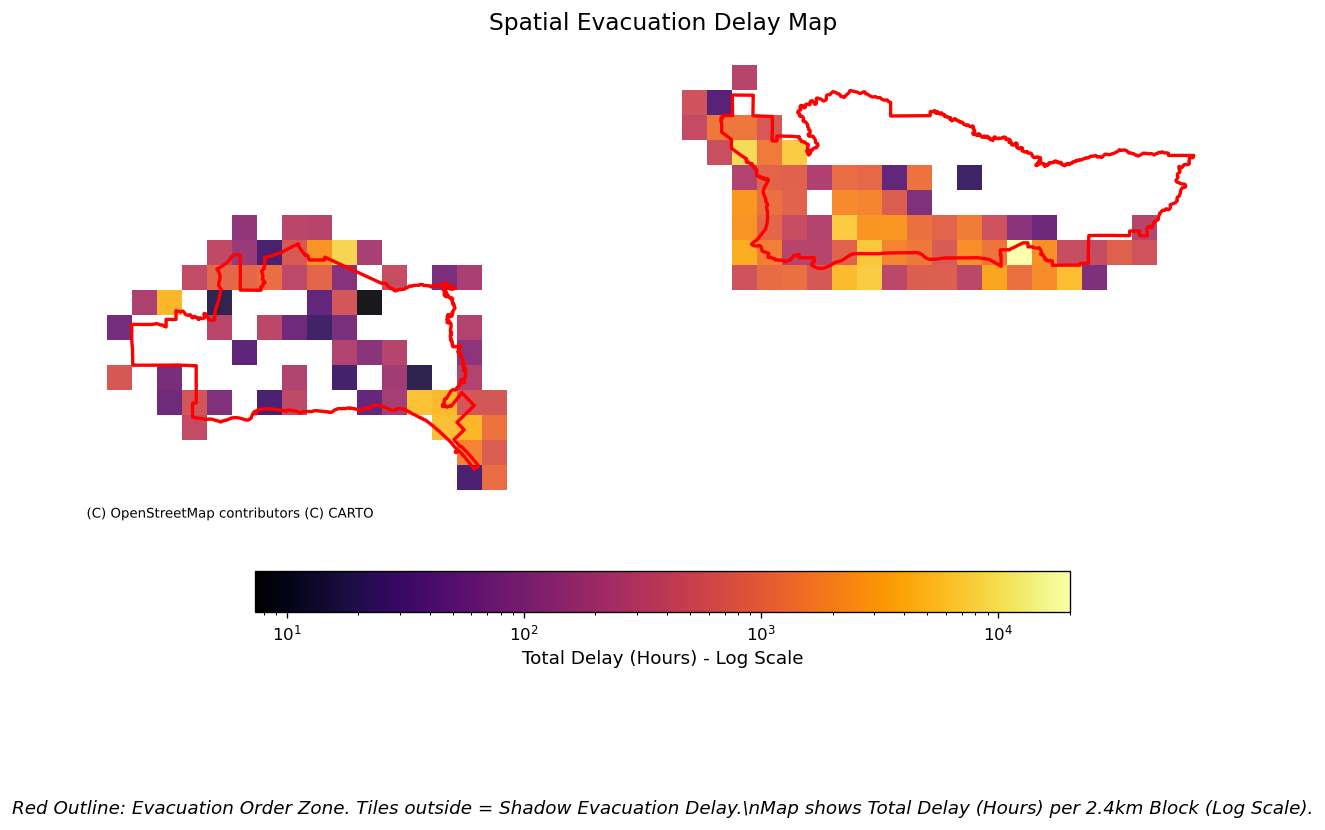

In [31]:
# Spatial Evacuation Delay Map
print('Plotting Spatial Evacuation Delay Map...')
if 'home_lat_4326' not in metrics.columns:
    # Using study_pop from earlier which retained EPSG 4326 geometry or join home.csv
    home_coords = study_pop[['ID', 'geometry']].copy()
    home_coords['home_lon_4326'] = home_coords.geometry.x
    home_coords['home_lat_4326'] = home_coords.geometry.y
    metrics = metrics.merge(home_coords[['ID', 'home_lon_4326', 'home_lat_4326']], on='ID', how='left')

metrics['DelayHours'] = (pd.to_datetime(metrics['DepartureDate']) - pd.to_datetime(metrics['OrderStart'])).dt.total_seconds() / 3600.0

emetrics.plot_delay_map(metrics, fire_zones, title="Spatial Evacuation Delay Map")


---
## 15 · Sub-Region Analysis (Altadena Bing Tiles)

This section demonstrates **post-pipeline spatial analysis** by overlaying
sub-region boundaries on the evacuation metrics. The Altadena Bing Tile
boundaries split the Eaton fire zone into East and West sub-regions.

> This is **not** part of the core EMBER pipeline — it shows how to extend
> the output with external spatial data for fire-specific analysis.

In [32]:
# Load Altadena sub-region boundaries
east_alt = gpd.read_file(os.path.join(DATA_DIR, 'Altadena_Bingtiles', 'East_Altadena_Bingtiles.geojson'))
west_alt = gpd.read_file(os.path.join(DATA_DIR, 'Altadena_Bingtiles', 'West_Altadena_Bingtiles.geojson'))

east_alt['SubRegion'] = 'East Altadena'
west_alt['SubRegion'] = 'West Altadena'
subregions = pd.concat([east_alt, west_alt], ignore_index=True)

# Ensure CRS consistency (files are EPSG:3857)
if subregions.crs is None:
    subregions = subregions.set_crs(epsg=3857)
subregions_4326 = subregions.to_crs(epsg=4326)

print(f'Loaded {len(subregions)} sub-region tiles')
print(subregions_4326['SubRegion'].value_counts())

Loaded 6 sub-region tiles
SubRegion
West Altadena    4
East Altadena    2
Name: count, dtype: int64


In [33]:
# Spatial join: assign SubRegion to Eaton evacuees based on home location
eaton_metrics = metrics[metrics['FireEvent'] == 'Eaton'].copy()

# Reconstruct home geometry from the classified homes (study_pop)
eaton_ids = eaton_metrics['ID'].values
eaton_homes = study_pop[study_pop['ID'].isin(eaton_ids)][['ID', 'geometry']].copy()
eaton_homes = eaton_homes.to_crs(epsg=4326)

# Spatial join with sub-region boundaries
joined = gpd.sjoin(eaton_homes, subregions_4326[['SubRegion', 'geometry']],
                   how='left', predicate='within')
joined = joined.drop_duplicates(subset='ID', keep='first')
joined['SubRegion'] = joined['SubRegion'].fillna('Other / Outside Altadena')

# Merge back into metrics
eaton_metrics = eaton_metrics.drop(columns=['SubRegion'], errors='ignore')
eaton_metrics = eaton_metrics.merge(joined[['ID', 'SubRegion']], on='ID', how='left')
eaton_metrics['SubRegion'] = eaton_metrics['SubRegion'].fillna('Other / Outside Altadena')

print('Eaton sub-region assignment:')
print(eaton_metrics['SubRegion'].value_counts())

Eaton sub-region assignment:
SubRegion
Other / Outside Altadena    2486
West Altadena                277
East Altadena                174
Name: count, dtype: int64


In [34]:
# Behavior summary by sub-region
for region in eaton_metrics['SubRegion'].unique():
    sub = eaton_metrics[eaton_metrics['SubRegion'] == region]
    print(f'\n── {region} ({len(sub):,} residents) ──')
    display(ebehavior.summary(sub['Category']))


── Other / Outside Altadena (2,486 residents) ──


,Category,Count,Percentage,Description
3,SELE,89,3.58,Self-Evacuee Leaving Early
1,PERE,436,17.54,Partially-compliant Evacuee (Early Returner)
2,FEUW,97,3.90,Fully-compliant Evacuee Under Warning
4,FEUO,71,2.86,Fully-compliant Evacuee Under Order
0,NER,1793,72.12,Non-Evacuee Resident



── West Altadena (277 residents) ──


,Category,Count,Percentage,Description
3,SELE,6,2.17,Self-Evacuee Leaving Early
1,PERE,45,16.25,Partially-compliant Evacuee (Early Returner)
2,FEUO,18,6.50,Fully-compliant Evacuee Under Order
0,NER,208,75.09,Non-Evacuee Resident



── East Altadena (174 residents) ──


,Category,Count,Percentage,Description
3,SELE,1,0.57,Self-Evacuee Leaving Early
1,PERE,24,13.79,Partially-compliant Evacuee (Early Returner)
2,FEUO,13,7.47,Fully-compliant Evacuee Under Order
0,NER,136,78.16,Non-Evacuee Resident


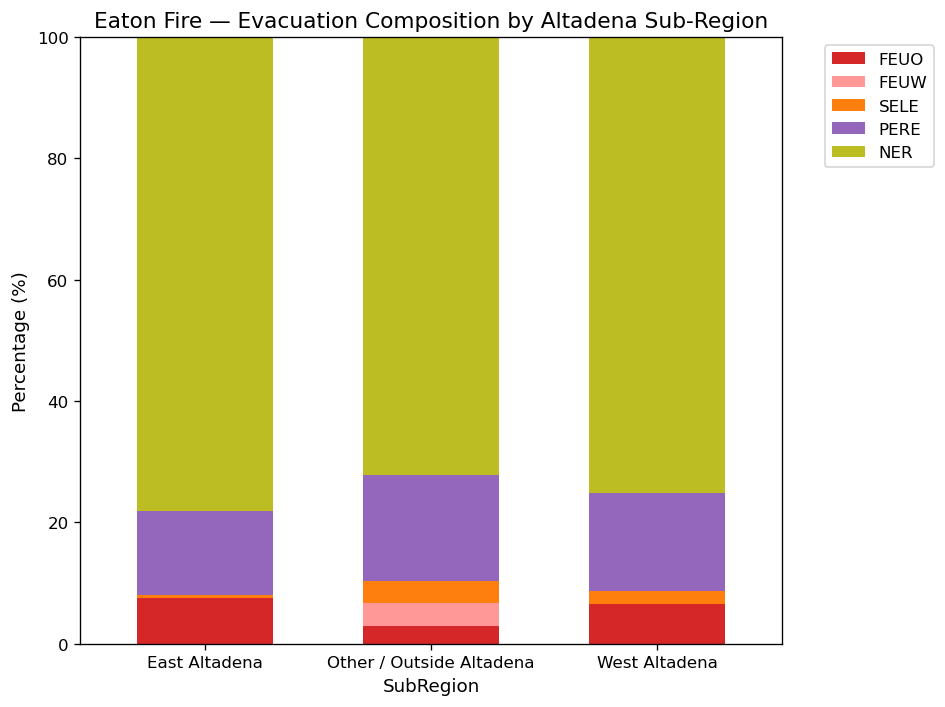

{'all': Category                       FEUO       FEUW       SELE         PERE  \
 SubRegion                                                                
 East Altadena             13 (7.5%)   0 (0.0%)   1 (0.6%)   24 (13.8%)   
 Other / Outside Altadena  71 (2.9%)  97 (3.9%)  89 (3.6%)  436 (17.5%)   
 West Altadena             18 (6.5%)   0 (0.0%)   6 (2.2%)   45 (16.2%)   
 
 Category                           NER  
 SubRegion                               
 East Altadena              136 (78.2%)  
 Other / Outside Altadena  1793 (72.1%)  
 West Altadena              208 (75.1%)  }

In [35]:
# Evacuation composition by sub-region
emetrics.plot_evacuation_composition(
    eaton_metrics, group_col='SubRegion',
    title='Eaton Fire — Evacuation Composition by Altadena Sub-Region'
)

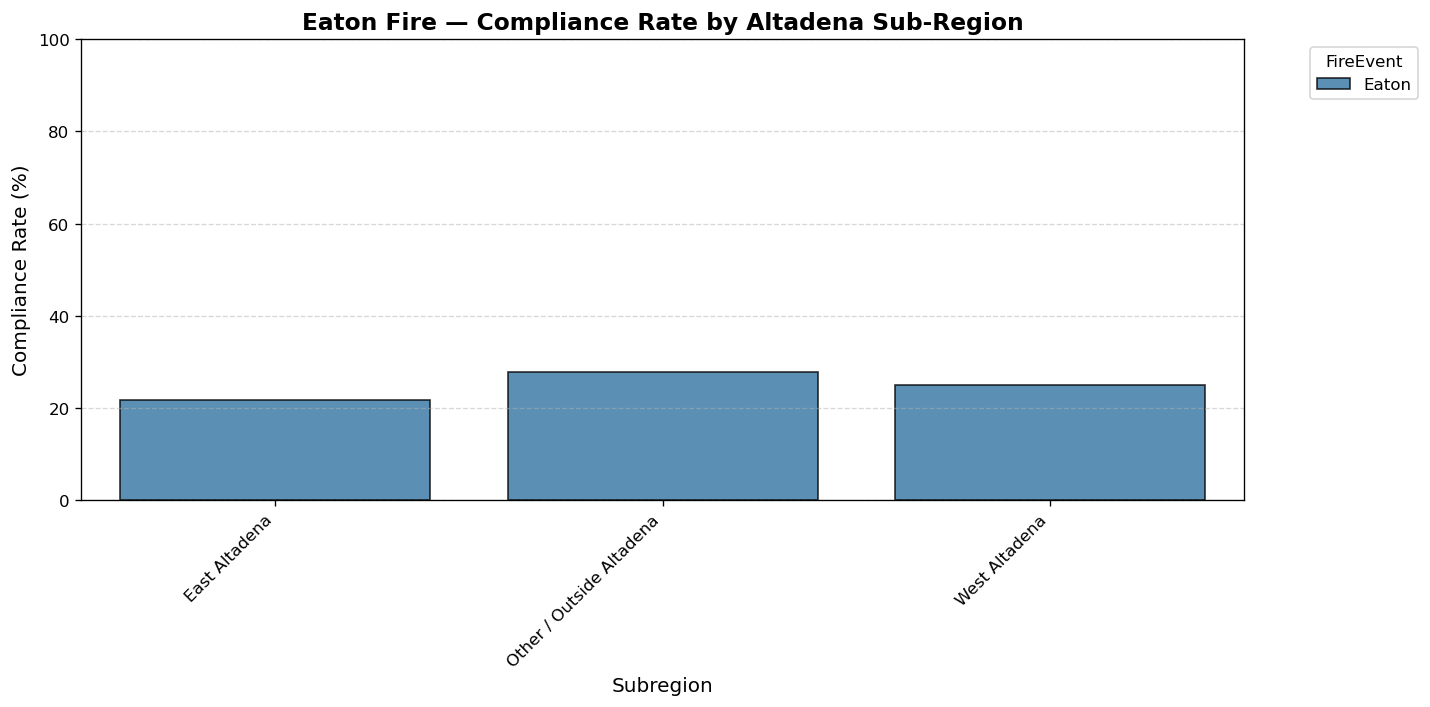

In [36]:
# Compliance by sub-region
emetrics.plot_compliance_by_region(
    eaton_metrics, region_col='SubRegion',
    title='Eaton Fire — Compliance Rate by Altadena Sub-Region'
)

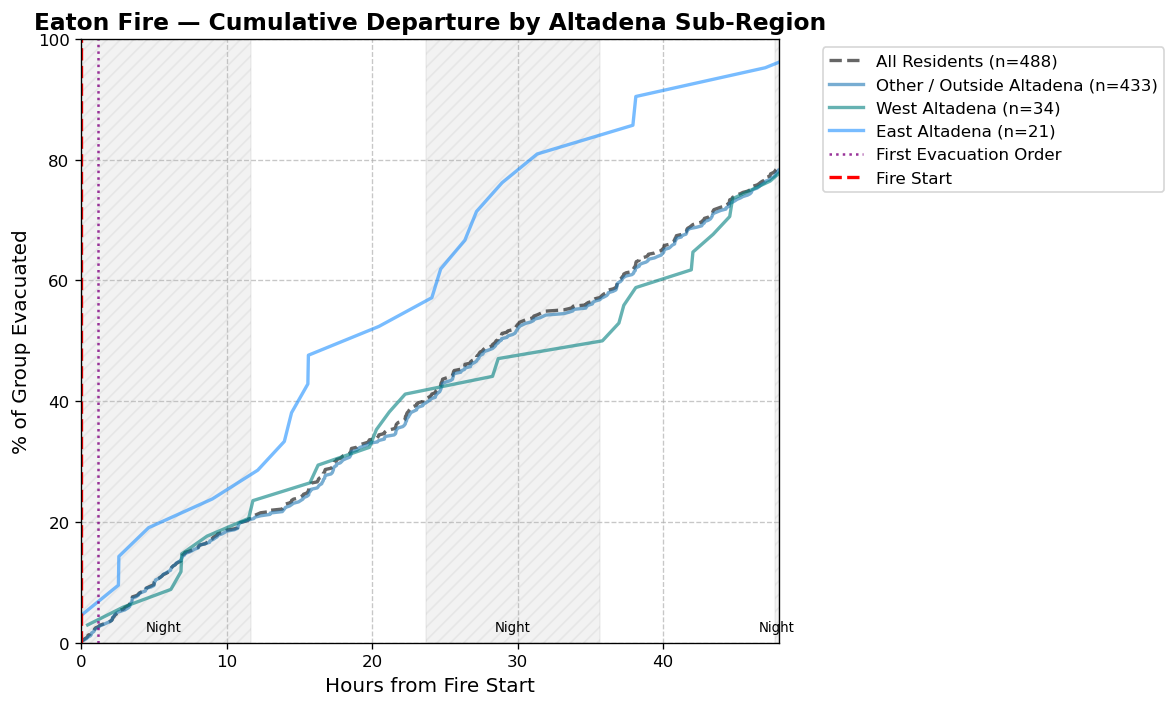

In [37]:
# Departure curves by sub-region
emetrics.plot_departure_curve(
    df=eaton_metrics, start_ref=EATON_START,
    
    night_shades=night_shades,
    group_col='SubRegion',
    title='Eaton Fire — Cumulative Departure by Altadena Sub-Region'
)